# Scheduling Circuits in Time

A `Circuit` in PyZX is a flat list of gates &mdash; it says *what* happens but
not *when*. When you call `circuit.to_graph(gate_durations=...)` the gates are
placed in discrete time by `pyzx.circuit.scheduling.schedule_gates`, using an
**as-soon-as-possible (ASAP)** rule:

* every qubit carries an integer clock, starting at 0;
* a gate starts at the largest clock over the qubits it touches;
* those clocks then advance by `max(duration, 1)`.

So independent gates end up on the **same** timestep, gates that share a qubit
are serialised, and the textual order of independent gates does not matter.
This notebook shows that on circuits where the effect is visible.

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, '../..')
import random
from collections import defaultdict
import pyzx as zx
from pyzx.circuit import Circuit
from pyzx.circuit.gates import CNOT, HAD, T
from pyzx.circuit.scheduling import schedule_gates, used_qubits

## A sequential-looking circuit with a lot of parallelism

18 gates, written one after another: a layer of Hadamards, some CNOTs, a layer
of `T` gates, and a final long-range CNOT.

18 gates


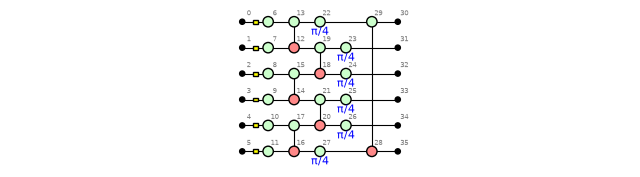

In [2]:
c = Circuit(6)
for q in range(6):
    c.add_gate(HAD(q))                                   # 6 independent gates
c.add_gate(CNOT(0, 1)); c.add_gate(CNOT(2, 3)); c.add_gate(CNOT(4, 5))  # 3 disjoint CNOTs
c.add_gate(CNOT(1, 2)); c.add_gate(CNOT(3, 4))           # bridge the pairs -> must wait
for q in range(6):
    c.add_gate(T(q))                                     # 6 independent gates
c.add_gate(CNOT(0, 5))                                   # spans the register -> waits

print(len(c.gates), "gates")
zx.draw_matplotlib(c,labels=True,h_edge_draw='box') 

If you just numbered the gates `0, 1, 2, ...` (one gate per timestep &mdash; the
naive reading) the circuit would be 18 deep. The ASAP schedule:

In [3]:
sched = schedule_gates(c.gates)

layers = defaultdict(list)
for g, (t, d) in zip(c.gates, sched):
    layers[t].append(str(g))

for t in sorted(layers):
    print(f"t={t}: " + ", ".join(layers[t]))

print()
print("naive depth (one gate per tick):", len(c.gates))
print("ASAP depth                     :", max(layers) + 1)

t=0: HAD(0), HAD(1), HAD(2), HAD(3), HAD(4), HAD(5)
t=1: CNOT(0,1), CNOT(2,3), CNOT(4,5)
t=2: CNOT(1,2), CNOT(3,4), T(0), T(5)
t=3: T(1), T(2), T(3), T(4), CNOT(0,5)

naive depth (one gate per tick): 18
ASAP depth                     : 4


18 gates collapse to **4 timesteps**:

* `t=0` &mdash; all six Hadamards, they touch disjoint qubits;
* `t=1` &mdash; the three disjoint CNOTs run together;
* `t=2` &mdash; the two bridging CNOTs, *plus* `T(0)` and `T(5)`, which slid
  forward because qubits 0 and 5 are idle at that point;
* `t=3` &mdash; the remaining `T` gates and the long-range `CNOT(0, 5)`.

## The schedule follows data dependencies, not list order

Rebuild the same circuit with every *independent* group shuffled. The
`(gate → timestep)` assignment is unchanged.

In [4]:
c2 = Circuit(6)
hs = [HAD(q) for q in range(6)]; random.Random(0).shuffle(hs)
for g in hs:
    c2.add_gate(g)
for g in [CNOT(4, 5), CNOT(0, 1), CNOT(2, 3), CNOT(3, 4), CNOT(1, 2)]:
    c2.add_gate(g)
ts = [T(q) for q in range(6)]; random.Random(1).shuffle(ts)
for g in ts:
    c2.add_gate(g)
c2.add_gate(CNOT(0, 5))

def gate_to_timestep(circ):
    s = schedule_gates(circ.gates)
    return sorted((str(g), t) for g, (t, _) in zip(circ.gates, s))

print("same (gate -> timestep) assignment:", gate_to_timestep(c) == gate_to_timestep(c2))

same (gate -> timestep) assignment: True


## It does not parallelise a genuine dependency chain

A GHZ ladder: each `CNOT` needs the result of the previous one, so ASAP cannot
compress it &mdash; depth stays equal to the number of gates.

In [5]:
ghz = Circuit(6)
ghz.add_gate(HAD(0))
for q in range(5):
    ghz.add_gate(CNOT(q, q + 1))

for g, (t, d) in zip(ghz.gates, schedule_gates(ghz.gates)):
    print(f"t={t}: {g}")
print("depth:", max(t for t, _ in schedule_gates(ghz.gates)) + 1)

t=0: HAD(0)
t=1: CNOT(0,1)
t=2: CNOT(1,2)
t=3: CNOT(2,3)
t=4: CNOT(3,4)
t=5: CNOT(4,5)
depth: 6


## Durations spread the schedule out

Same parallel circuit, but now a `CNOT` occupies 3 ticks. Gates on a qubit that
is mid-CNOT have to wait, `time_depth` grows, and the squiggly wires show where
the qubit is busy.

In [6]:
g_fast = c.to_graph(gate_durations={})            # every gate instantaneous
g_slow = c.to_graph(gate_durations={"CNOT": 3})   # CNOT takes 3 ticks

print("all instantaneous :", zx.spacetime_metrics(g_fast))
print("CNOT takes 3      :", zx.spacetime_metrics(g_slow))

all instantaneous : {'num_timesteps': 4, 'time_depth': 4, 'spacetime_volume': 24, 'total_delay': 0}
CNOT takes 3      : {'num_timesteps': 5, 'time_depth': 9, 'spacetime_volume': 48, 'total_delay': 36}


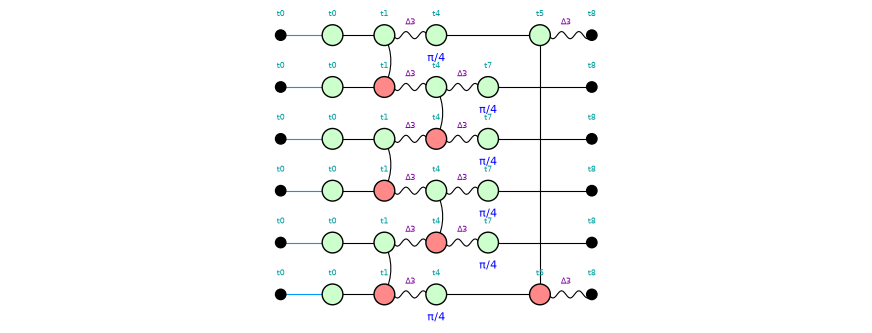

In [7]:
zx.draw_matplotlib(g_slow, show_time=True, figsize=(11, 4))

`time_depth` went from 4 to 9, and `spacetime_volume` (occupied
qubit-ticks) grew because each CNOT now paints three cells per qubit instead of
one. `num_timesteps` (the number of distinct start ticks) barely changes &mdash;
the gates still start in the same few waves, they just take longer to finish.

## Summary

`schedule_gates` / `to_graph(gate_durations=...)` turn a gate list into a
time-annotated ZX-diagram by ASAP scheduling: independent gates parallelise,
dependent gates serialise, list order is irrelevant, and per-gate-type durations
stretch the timeline. See [Time Dependency for Circuits](time_dependency.ipynb)
for the annotations, metrics, `time_slice` and drawing.